# Chapter 6: Linear Regression

## Author: Rahul Bhadani

# 1. Generating Scatter Plot

In [1]:
#!uv add polars
#!uv add scikit-learn
#!uv add seaborn

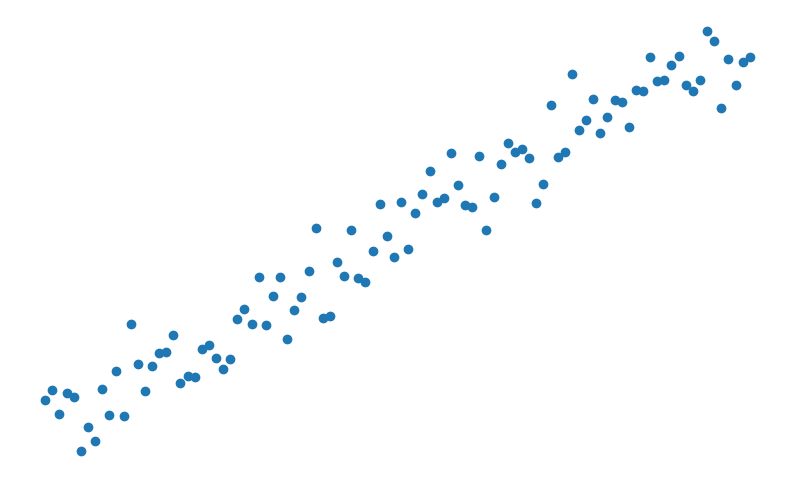

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(0, 10, 100)

# Create a line equation
y = 3.0*x + 77.0

# Add Gaussian noise
mu = 0  # Mean of the Gaussian noise
sigma = 2  # Standard deviation of the Gaussian noise
noise = np.random.normal(mu, sigma, y.shape)
y_noisy = y + noise

## Make a plot
# Plot the results
fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(x, y_noisy)
plt.axis('off')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
fig.patch.set_alpha(0.0)
plt.savefig('figures/scatterplot.png', transparent=True)
plt.show()

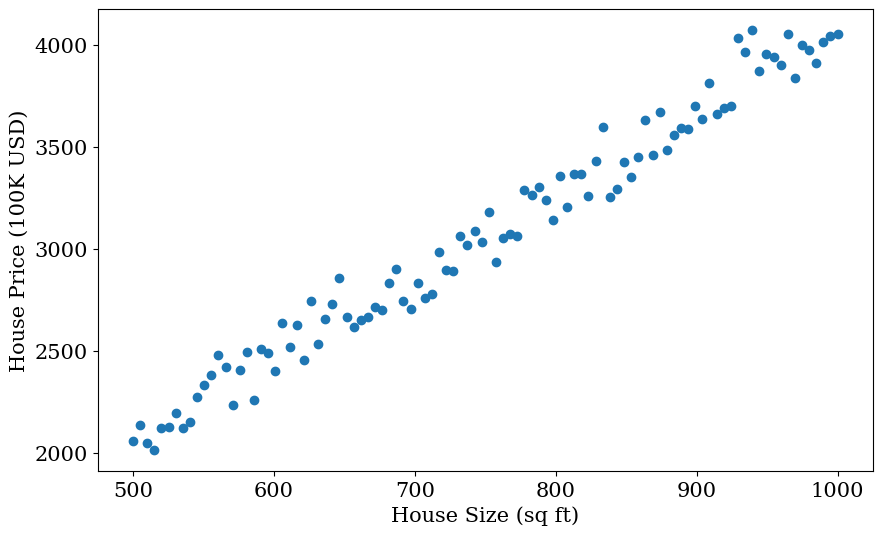

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 15

# Generate x values
x = np.linspace(500, 1000, 100)

# Create a line equation
y = 4.0*x + 7.0

# Add Gaussian noise
mu = 60  # Mean of the Gaussian noise
sigma = 102  # Standard deviation of the Gaussian noise
noise = np.random.normal(mu, sigma, y.shape)
y_noisy = y + noise

## Make a plot
# Plot the results
fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(x, y_noisy)
fig.patch.set_alpha(0.0)
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price (100K USD)')
plt.savefig('figures/scatterplot_2.png', transparent=True)
plt.show()

# 2. SLR Using Scikit-Learning

In [4]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from statistics import mean

# Read data
data = pl.read_csv("../Data/HousePrices/kc_house_data.csv")
data = data.drop_nulls()
#remove drop na (not a number)
data.head()

id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
i64,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64
7129300520,"""20141013T000000""",221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,"""20141209T000000""",538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
5631500400,"""20150225T000000""",180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,"""20141209T000000""",604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,"""20150218T000000""",510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Drop the non-sensical variables that are not useful for regression

In [5]:
dropColumns = ['id', 'date', 'zipcode']
data = data.drop(dropColumns)
data.head()

price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64
221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.721,-122.319,1690,7639
180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


## Get the dependent and independent variable

In [6]:
y = data['price']
X = data[['sqft_living']]  # Ensure X is a 2D array because scikit-learn Linear Regressione expects 2D Array (n_samples, n_features)).  Even if there is only one feature, it still needs to be shaped as a 2D array with one column.


In [7]:
y

price
f64
221900.0
538000.0
180000.0
604000.0
510000.0
…
360000.0
400000.0
402101.0


In [8]:
X

sqft_living
i64
1180
2570
770
1960
1680
…
1530
2310
1020


## Make a plot between dependent and independent variable

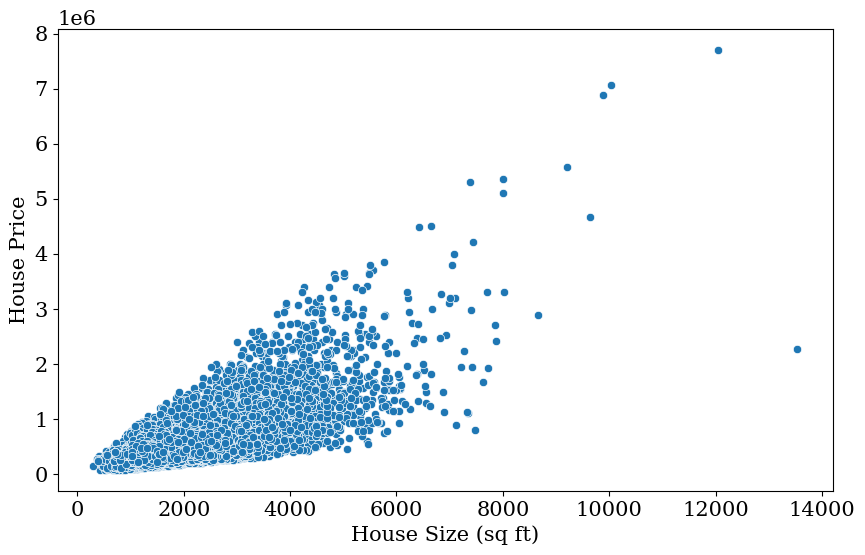

In [9]:
## Make a plot
# Plot the results
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
#plt.scatter(data['sqft_living'], data['price'])
# We will use seaborn for plotting
sns.scatterplot(x='sqft_living', y='price', data=data, ax=ax)

fig.patch.set_alpha(0.0)
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price')
plt.savefig('figures/scatterplot_3.png', transparent=True)
plt.show()

## Dividing the data into training and testing set


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

## Building the Linear Regression Model using One Feature Only

In [11]:
linearModel = LinearRegression()
linearModel.fit(X_train, y_train)
 
# Evaluating the Linear Regression model on the test dataset
# coefficient of determination of the prediction
print(linearModel.score(X_test, y_test))

0.48339610635004915


Since the score is 0.469, it is not a good score. But nonetheless, let's use that to make a prediction using a new data points

## Make a Prediction on trained model using a new data point

In [12]:
# Create a new data point
# Alternative: new_data_point = [[5000]]  # Note the double brackets to make it a 2D array

new_data_point = pl.DataFrame({'sqft_living': [5000]})

# Make the prediction
predicted_price = linearModel.predict(new_data_point)

print(f"Predicted price for a house with 5000 sqft living area: ${predicted_price[0]:,.2f}")

Predicted price for a house with 5000 sqft living area: $1,363,314.96


# 3. Toluca Dataset Example

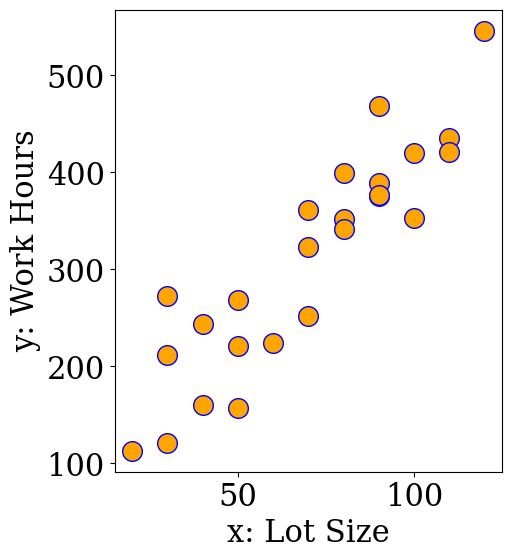

In [13]:
toluca = pl.read_csv('../Data/Toluca/toluca.txt', separator='\t')
x = toluca['LotSize'].to_numpy()
y = toluca['WorkHours'].to_numpy()
# plt.scatter(x, y, c='orange', edgecolors='blue')
# plt.xlim([0, 123])
plt.rcParams['font.size'] = 22



fig, ax = plt.subplots(figsize=(5, 6))
plt.scatter(x, y, c='orange', edgecolors='blue', s=200)
fig.patch.set_alpha(0.0)
plt.xlabel('x: Lot Size')
plt.ylabel('y: Work Hours')
plt.savefig('figures/Toluca_Scatter.pdf', transparent=True)

## Fitting a Regression Model

[3.57020202]
62.36585858585849


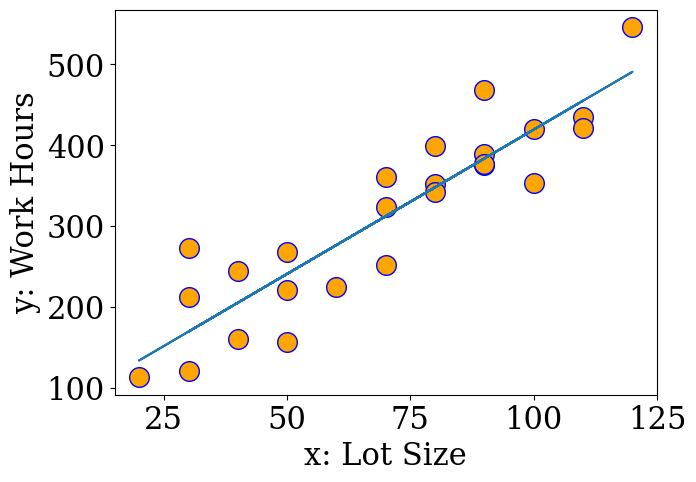

In [14]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x.reshape((-1, 1)), y)
print(reg.coef_) # w_1
print(reg.intercept_) #w_0
fig, ax = plt.subplots(figsize=(7,5))
plt.scatter(x, y, c='orange', edgecolors='blue', s=200)
fig.patch.set_alpha(0.0)
plt.xlabel('x: Lot Size')
plt.ylabel('y: Work Hours')
yhat = reg.coef_*x + reg.intercept_
plt.plot(x, yhat)
plt.savefig('figures/Toluca_Regressed.pdf', transparent=True)

## Prediction on the Fitted Model

In [15]:
reg.predict([[50.0], [100.0]])

array([240.8759596 , 419.38606061])

## Calculating Goodness of Fit

In [16]:
# Calculate and print R^2
r_squared = reg.score(x.reshape((-1, 1)), y)
print("R^2 (Coefficient of Determination):", r_squared)

R^2 (Coefficient of Determination): 0.8215334744346307


# 4. Percentile Calculation for Chi^2

In [17]:
from scipy.stats import chi2
# Given percentile and degrees of freedom
percentile = 0.90
degrees_of_freedom = 5
# Calculate the 90th percentile of the chi-squared distribution
chi2_value = chi2.ppf(percentile, degrees_of_freedom)
print(f"The 90th percentile of the chi-squared distribution with {degrees_of_freedom} degrees of freedom is: {chi2_value:.2f}")


The 90th percentile of the chi-squared distribution with 5 degrees of freedom is: 9.24


# 5. Linear Regression on a Synthetic Dataset using PyTorch

Epoch [10/10], Loss: 188.6165
Learned weight: 10.0400
Learned bias: 0.0424


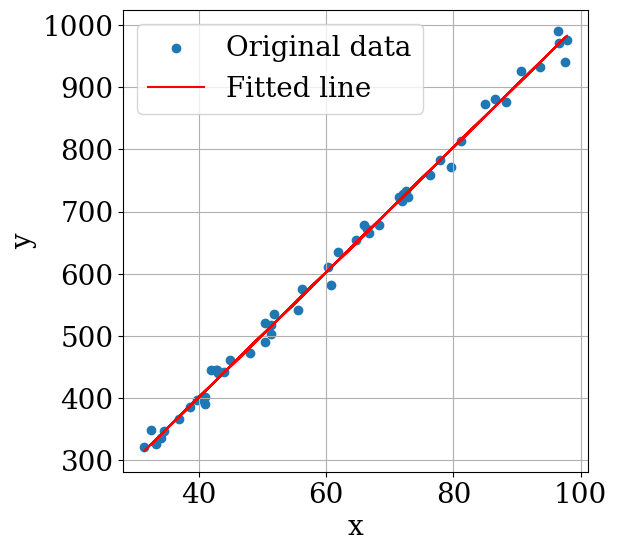

In [46]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
x = np.random.uniform(30, 100, 50)  # Random x values
y = 3.0 + 10.0 * x + np.random.normal(0.11, 15, 50)  # y = 4 + 3x + Gaussian noise

# Convert data to PyTorch tensors
X = torch.tensor(x, dtype=torch.float32).view(-1, 1)
Y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Initialize parameters (weights)
w_1 = torch.randn(1, requires_grad=True, dtype=torch.float32)  # Weight for X
w_0 = torch.randn(1, requires_grad=True, dtype=torch.float32)  # Bias term

# Initialize parameters (weights) with zero
# w_1 = torch.zeros(1, requires_grad=True, dtype=torch.float32)  # Weight for X
# w_0 = torch.zeros(1, requires_grad=True, dtype=torch.float32)  # Bias term


# Lists to store w_1, w_0 values over epochs
w_1_vals = []
w_0_vals = []

# Define the Linear Regression model manually
def model(X):
    return w_1 * X + w_0

# Loss function: Mean Squared Error
def mse_loss(Y_pred, Y_true):
    return torch.mean((Y_pred - Y_true)**2)

# Optimizer: Using SGD (Stochastic Gradient Descent)
learning_rate = 0.0001
epochs = 10
for epoch in range(epochs):
    # Forward pass: Compute predicted y
    Y_pred = model(X)
    
    # Compute loss
    loss = mse_loss(Y_pred, Y)
    
    # Backward pass: Compute gradients
    loss.backward()
    
    # Update parameters manually
    with torch.no_grad():
        w_1 -= learning_rate * w_1.grad
        w_0 -= learning_rate * w_0.grad
        
        # Zero the gradients after updating
        w_1.grad.zero_()
        w_0.grad.zero_()
        
    # Store the values of w_1 and w_0 at each epoch
    w_1_vals.append(w_1.item())
    w_0_vals.append(w_0.item())
    
    # Print the loss every 10 epochs
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Print the learned parameters
print(f'Learned weight: {w_1.item():.4f}')
print(f'Learned bias: {w_0.item():.4f}')


fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.size'] = 20
# Plot the results
plt.scatter(x, y, label='Original data')
plt.plot(x, w_1.item() * x + w_0.item(), label='Fitted line', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(which='both')
plt.savefig('linear_regression.pdf')
plt.show()



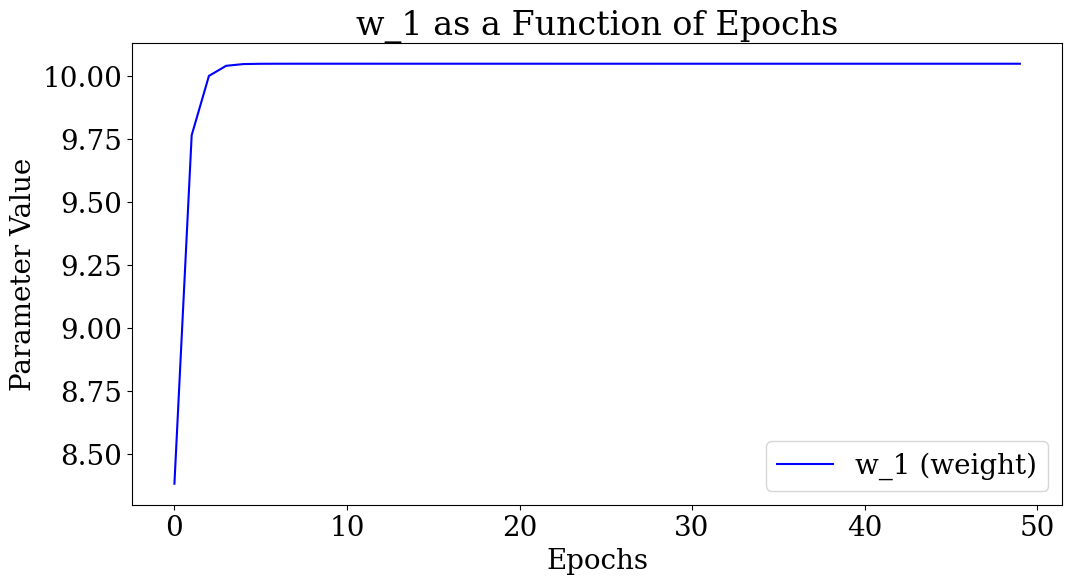

In [28]:
# Plot w_1 and w_0 as a function of epochs
fig, ax = plt.subplots(figsize=(12, 6))

# Plot w_1 and w_0 over epochs
ax.plot(range(epochs), w_1_vals, label='w_1 (weight)', color='blue')
ax.set_xlabel('Epochs')
ax.set_ylabel('Parameter Value')
ax.set_title('w_1 as a Function of Epochs')
ax.legend()

plt.show()


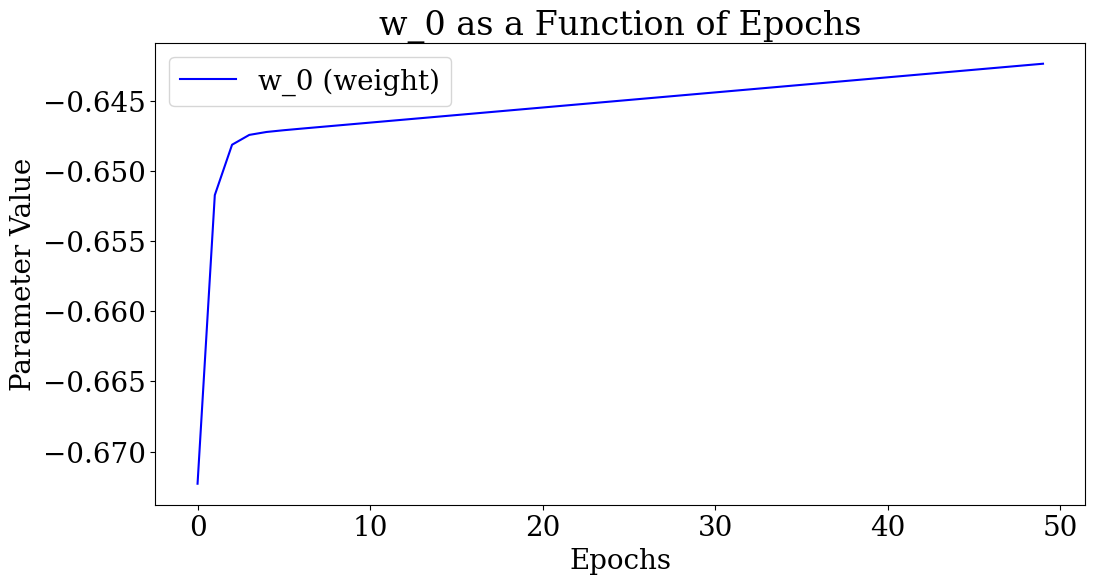

In [29]:
# Plot w_1 and w_0 as a function of epochs
fig, ax = plt.subplots(figsize=(12, 6))

# Plot w_1 and w_0 over epochs
ax.plot(range(epochs), w_0_vals, label='w_0 (weight)', color='blue')
ax.set_xlabel('Epochs')
ax.set_ylabel('Parameter Value')
ax.set_title('w_0 as a Function of Epochs')
ax.legend()

plt.show()


In [30]:
# New data points
new_data_points = torch.tensor([4.5, 19.91, 59.23], dtype=torch.float32)

# Make predictions
predictions = model(new_data_points).detach().numpy()

# Print predictions
for x_new, pred in zip(new_data_points, predictions):
    print(f"The predicted value for x={x_new.item()} is {pred}")

The predicted value for x=4.5 is 44.58369445800781
The predicted value for x=19.90999984741211 is 199.4578399658203
The predicted value for x=59.22999954223633 is 594.6331176757812


In [31]:
# Predictions
y_hat = model(X)

# MSE (Mean Squared Error)
MSE = torch.mean((Y - y_hat) ** 2)

print(f'MSE: {MSE}')
# SSE (Sum of Squared Errors)
SSE = torch.sum((Y - y_hat) ** 2)

# SSTO (Total Sum of Squares)
SSTO = torch.sum((Y - torch.mean(Y)) ** 2)

# R-squared
R_squared = 1 - (SSE / SSTO)

# Print the R-squared value
print(f'R-squared: {R_squared.item():.4f}')

# Variance of w_1
variance_w1 = MSE / torch.sum((X - torch.mean(X)) ** 2)

# Variance of w_0
variance_w0 = MSE * (1 / len(x) + (torch.mean(X) ** 2) / torch.sum((X - torch.mean(X)) ** 2))

# Print the variances
print(f'Variance of w_1: {variance_w1.item():.4f}')
print(f'Variance of w_0: {variance_w0.item():.4f}')

MSE: 85.30107116699219
R-squared: 0.9979
Variance of w_1: 0.0043
Variance of w_0: 17.6585


In [23]:
import torch

import scipy.stats as stats

# Degrees of freedom
df = 8
# Quantile
p = 0.975

# Calculate the t-statistic (quantile) using scipy
t_statistic = stats.t.ppf(p, df)

# Compute w1_upper and w1_lower
w1_upper = w_1 + t_statistic * torch.sqrt(variance_w1)
w1_lower = w_1 - t_statistic * torch.sqrt(variance_w1)

# Print the results
print(f'w1_upper: {w1_upper.item():.4f}')
print(f'w1_lower: {w1_lower.item():.4f}')

w1_upper: 3.2038
w1_lower: 2.9025


In [24]:
w0_upper = w_0 + t_statistic*torch.sqrt(variance_w0)
w0_lower = w_0 - t_statistic*torch.sqrt(variance_w0)
# Print the results
print(f'w0_upper: {w0_upper.item():.4f}')
print(f'w0_lower: {w0_lower.item():.4f}')

w0_upper: 9.8629
w0_lower: -9.5423


In [25]:
x_bar = torch.mean(X)  # Mean of X
sum_x_i_x_bar_sq = torch.sum((X - x_bar) ** 2)  # Sum of (x_i - x_bar)^2
n = len(X)
variance_y = MSE * ((1.0/n) +  ((X - x_bar) ** 2 / sum_x_i_x_bar_sq))
std_y = torch.sqrt(variance_y)
std_y = std_y *10 #enhance the variance for display purposes
# variance_y

Text(0.5, 1.0, 'WHS Band')

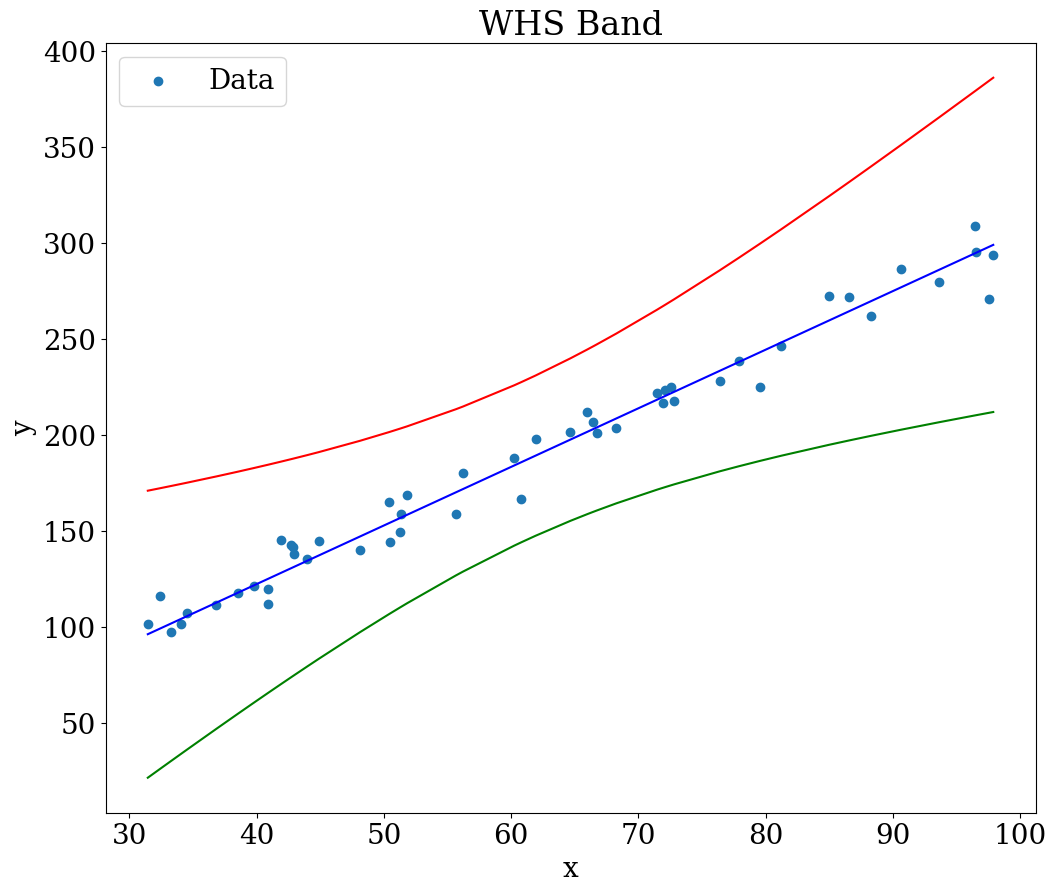

In [26]:
from scipy.stats import f

# Degrees of freedom
df1 = 2
df2 = len(x) - 2  # replace n with your sample size

# Quantile
p = 1 - 0.05  # replace alpha with your significance level

# Calculate the F-statistic
f_statistic = f.ppf(p, df1, df2)


yh = w_1.item() * x + w_0.item()


y_upper = yh + f_statistic*std_y.detach().numpy().reshape(1,-1)[0]
y_lower = yh - f_statistic*std_y.detach().numpy().reshape(1,-1)[0]



# Sort x, y_lower, and y_upper using the sorted indices
sorted_indices = np.argsort(x)
x_ = x[sorted_indices]
yh_ = yh[sorted_indices]
y_ = y[sorted_indices]
y_lower_ = y_lower[sorted_indices]
y_upper_ = y_upper[sorted_indices]

# Plot the data and the learned line
plt.figure(figsize=(12,10))
plt.scatter(x_, y_, label='Data')
plt.plot(x_, yh_, color='blue')
plt.plot(x_, y_lower_, color='green')
plt.plot(x_, y_upper_, color='red')
#plt.fill_between(x_sorted, y_lower_sorted, y_upper_sorted, color='gray', alpha=0.5)  
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('WHS Band')

In [49]:
import scipy.stats as stats
import numpy as np

# Calculate t(0.975, 3) - this is the critical value for t-distribution
# with 3 degrees of freedom at the 97.5th percentile

# Method 1: Using scipy.stats.t.ppf (percent point function)
# ppf gives the inverse of the CDF (cumulative distribution function)
alpha = 0.975  # percentile
df = 3         # degrees of freedom

t_critical = stats.t.ppf(alpha, df)
print(f"t(0.975, 3) = {t_critical:.6f}")

# Method 2: More explicit calculation showing the relationship
# For a two-tailed test with α = 0.05, we need t(0.975, df)
# because 1 - α/2 = 1 - 0.05/2 = 0.975

confidence_level = 0.95  # 95% confidence
alpha_two_tail = 1 - confidence_level  # 0.05
percentile = 1 - alpha_two_tail/2       # 0.975

t_critical_method2 = stats.t.ppf(percentile, df)
print(f"\nUsing confidence level approach:")
print(f"For 95% confidence with df=3: t(0.975, 3) = {t_critical_method2:.6f}")

# Additional useful information
print(f"\nAdditional t-distribution information for df=3:")
print(f"t(0.95, 3)  = {stats.t.ppf(0.95, 3):.6f}")   # one-tailed 5%
print(f"t(0.99, 3)  = {stats.t.ppf(0.99, 3):.6f}")   # one-tailed 1%
print(f"t(0.995, 3) = {stats.t.ppf(0.995, 3):.6f}")  # two-tailed 1%

# Verification: Check the CDF of our result
cdf_check = stats.t.cdf(t_critical, df)
print(f"\nVerification: CDF of {t_critical:.6f} with df=3 = {cdf_check:.6f}")

# Compare with normal distribution (should be larger for small df)
normal_critical = stats.norm.ppf(0.975)
print(f"\nComparison with normal distribution:")
print(f"Normal(0.975) = {normal_critical:.6f}")
print(f"t(0.975, 3)   = {t_critical:.6f}")
print(f"Difference    = {t_critical - normal_critical:.6f}")

t(0.975, 3) = 3.182446

Using confidence level approach:
For 95% confidence with df=3: t(0.975, 3) = 3.182446

Additional t-distribution information for df=3:
t(0.95, 3)  = 2.353363
t(0.99, 3)  = 4.540703
t(0.995, 3) = 5.840909

Verification: CDF of 3.182446 with df=3 = 0.975000

Comparison with normal distribution:
Normal(0.975) = 1.959964
t(0.975, 3)   = 3.182446
Difference    = 1.222482


=== Linear Regression with PyTorch ===
True parameters: slope=2.5, intercept=-1.2

Fitted parameters: slope=2.1854, intercept=-0.1700

Model Summary:
R-squared: 0.9495
RMSE: 1.6444
Training epochs: 10

95% Confidence Intervals:
w_1 (slope): [2.0746, 2.2962]
w_0 (intercept): [-0.5013, 0.1613]


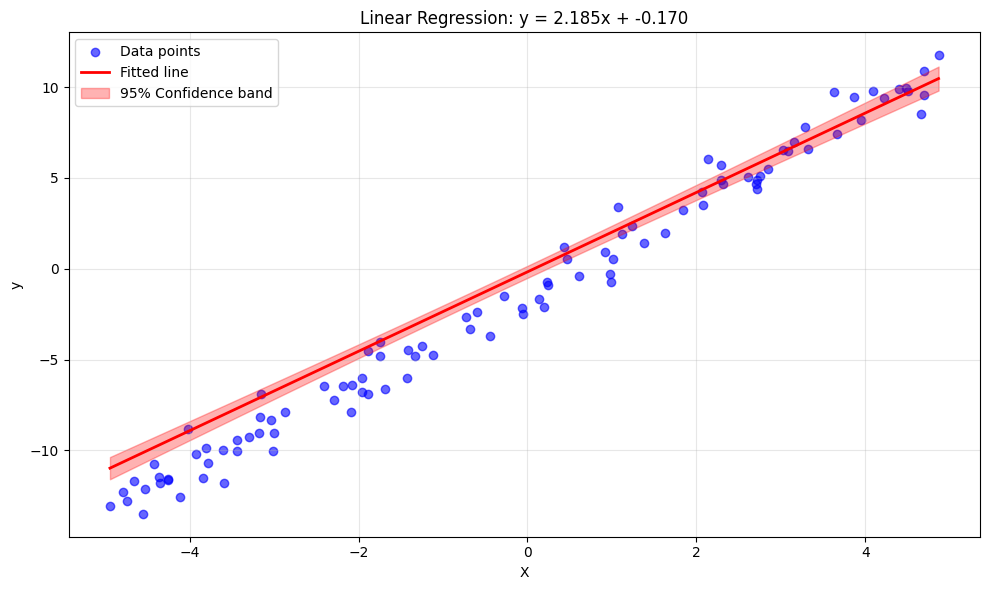


90% CI for slope: [2.0927, 2.2781]

95% CI for slope: [2.0746, 2.2962]

99% CI for slope: [2.0387, 2.3321]


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from typing import Tuple, Optional
import warnings

class LinearRegression:
    """
    A PyTorch-based Linear Regression implementation for one variable.
    
    Model: y = w_1 * x + w_0
    Loss: Mean Squared Error
    
    Features:
    - Gradient-based optimization using PyTorch
    - Confidence intervals for parameters w_1 and w_0
    - Visualization with confidence bands
    """
    
    def __init__(self, learning_rate: float = 0.01, max_epochs: int = 1000, 
                 tolerance: float = 1e-6):
        """
        Initialize the Linear Regression model.
        
        Args:
            learning_rate: Learning rate for gradient descent
            max_epochs: Maximum number of training epochs
            tolerance: Convergence tolerance for early stopping
        """
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.tolerance = tolerance
        
        # Model parameters
        self.w_1 = nn.Parameter(torch.randn(1, requires_grad=True))  # slope
        self.w_0 = nn.Parameter(torch.randn(1, requires_grad=True))  # intercept
        
        # Training data storage
        self.X_train = None
        self.y_train = None
        
        # Model statistics for confidence intervals
        self.n_samples = None
        self.residual_sum_squares = None
        self.X_mean = None
        self.X_var = None
        self.fitted = False
        
        # Loss function and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.SGD([self.w_1, self.w_0], lr=self.learning_rate)
        
        # Training history
        self.loss_history = []
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the linear model.
        
        Args:
            X: Input tensor of shape (n_samples,)
            
        Returns:
            Predictions tensor of shape (n_samples,)
        """
        return self.w_1 * X + self.w_0
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegression':
        """
        Fit the linear regression model to the training data.
        
        Args:
            X: Input features of shape (n_samples,)
            y: Target values of shape (n_samples,)
            
        Returns:
            self: Returns the fitted model instance
        """
        # Convert to PyTorch tensors
        self.X_train = torch.tensor(X, dtype=torch.float32)
        self.y_train = torch.tensor(y, dtype=torch.float32)
        self.n_samples = len(X)
        
        # Store statistics for confidence intervals
        self.X_mean = float(np.mean(X))
        self.X_var = float(np.var(X, ddof=1))  # Sample variance
        
        # Training loop
        prev_loss = float('inf')
        
        for epoch in range(self.max_epochs):
            # Zero gradients
            self.optimizer.zero_grad()
            
            # Forward pass
            y_pred = self.forward(self.X_train)
            
            # Compute loss
            loss = self.criterion(y_pred, self.y_train)
            
            # Backward pass
            loss.backward()
            
            # Update parameters
            self.optimizer.step()
            
            # Store loss history
            current_loss = loss.item()
            self.loss_history.append(current_loss)
            
            # Check for convergence
            if abs(prev_loss - current_loss) < self.tolerance:
                print(f"Converged after {epoch + 1} epochs")
                break
            
            prev_loss = current_loss
        
        # Compute residual sum of squares for confidence intervals
        with torch.no_grad():
            y_pred = self.forward(self.X_train)
            residuals = self.y_train - y_pred
            self.residual_sum_squares = float(torch.sum(residuals ** 2))
        
        self.fitted = True
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Make predictions on new data.
        
        Args:
            X: Input features of shape (n_samples,)
            
        Returns:
            Predictions as numpy array
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        
        X_tensor = torch.tensor(X, dtype=torch.float32)
        
        with torch.no_grad():
            predictions = self.forward(X_tensor)
        
        return predictions.numpy()
    
    def get_parameters(self) -> Tuple[float, float]:
        """
        Get the fitted parameters.
        
        Returns:
            Tuple of (w_1, w_0) - slope and intercept
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before accessing parameters")
        
        return float(self.w_1.item()), float(self.w_0.item())
    
    def parameter_confidence_intervals(self, confidence_level: float = 0.95) -> dict:
        """
        Compute confidence intervals for parameters w_1 and w_0.
        
        Args:
            confidence_level: Confidence level (e.g., 0.95 for 95%)
            
        Returns:
            Dictionary containing confidence intervals for both parameters
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before computing confidence intervals")
        
        # Degrees of freedom
        df = self.n_samples - 2
        
        # Critical t-value
        alpha = 1 - confidence_level
        t_critical = stats.t.ppf(1 - alpha/2, df)
        
        # Standard error of regression
        mse = self.residual_sum_squares / df
        se_regression = np.sqrt(mse)
        
        # Standard error for w_1 (slope)
        se_w1 = se_regression / np.sqrt(self.n_samples * self.X_var)
        
        # Standard error for w_0 (intercept)
        se_w0 = se_regression * np.sqrt(1/self.n_samples + self.X_mean**2 / (self.n_samples * self.X_var))
        
        # Get current parameter values
        w_1_val, w_0_val = self.get_parameters()
        
        # Compute confidence intervals
        w_1_ci = (
            w_1_val - t_critical * se_w1,
            w_1_val + t_critical * se_w1
        )
        
        w_0_ci = (
            w_0_val - t_critical * se_w0,
            w_0_val + t_critical * se_w0
        )
        
        return {
            'w_1_confidence_interval': w_1_ci,
            'w_0_confidence_interval': w_0_ci,
            'confidence_level': confidence_level,
            'standard_errors': {
                'se_w1': se_w1,
                'se_w0': se_w0,
                'se_regression': se_regression
            }
        }
    
    def plot_regression_with_confidence_band(self, confidence_level: float = 0.95, 
                                           figsize: Tuple[int, int] = (10, 6),
                                           title: Optional[str] = None) -> plt.Figure:
        """
        Plot the fitted regression line with confidence band.
        
        Args:
            confidence_level: Confidence level for the band
            figsize: Figure size tuple
            title: Optional plot title
            
        Returns:
            matplotlib Figure object
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before plotting")
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Convert training data to numpy for plotting
        X_np = self.X_train.numpy()
        y_np = self.y_train.numpy()
        
        # Create prediction range
        X_range = np.linspace(X_np.min(), X_np.max(), 100)
        y_pred_range = self.predict(X_range)
        
        # Compute confidence band
        df = self.n_samples - 2
        alpha = 1 - confidence_level
        t_critical = stats.t.ppf(1 - alpha/2, df)
        
        mse = self.residual_sum_squares / df
        se_regression = np.sqrt(mse)
        
        # Standard error for predictions (confidence band)
        X_centered = X_range - self.X_mean
        se_pred = se_regression * np.sqrt(1/self.n_samples + X_centered**2 / (self.n_samples * self.X_var))
        
        # Confidence band bounds
        margin_of_error = t_critical * se_pred
        y_upper = y_pred_range + margin_of_error
        y_lower = y_pred_range - margin_of_error
        
        # Plot data points
        ax.scatter(X_np, y_np, alpha=0.6, color='blue', label='Data points')
        
        # Plot regression line
        ax.plot(X_range, y_pred_range, 'r-', linewidth=2, label='Fitted line')
        
        # Plot confidence band
        ax.fill_between(X_range, y_lower, y_upper, alpha=0.3, color='red', 
                       label=f'{int(confidence_level*100)}% Confidence band')
        
        # Get parameter values for display
        w_1_val, w_0_val = self.get_parameters()
        
        # Labels and title
        ax.set_xlabel('X')
        ax.set_ylabel('y')
        if title is None:
            title = f'Linear Regression: y = {w_1_val:.3f}x + {w_0_val:.3f}'
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def summary(self) -> dict:
        """
        Provide a summary of the fitted model.
        
        Returns:
            Dictionary containing model summary statistics
        """
        if not self.fitted:
            raise ValueError("Model must be fitted before generating summary")
        
        w_1_val, w_0_val = self.get_parameters()
        
        # R-squared calculation
        y_mean = float(torch.mean(self.y_train))
        ss_tot = float(torch.sum((self.y_train - y_mean) ** 2))
        r_squared = 1 - (self.residual_sum_squares / ss_tot)
        
        # Adjusted R-squared
        adj_r_squared = 1 - ((1 - r_squared) * (self.n_samples - 1) / (self.n_samples - 2))
        
        # RMSE
        rmse = np.sqrt(self.residual_sum_squares / self.n_samples)
        
        return {
            'parameters': {
                'w_1 (slope)': w_1_val,
                'w_0 (intercept)': w_0_val
            },
            'model_fit': {
                'r_squared': r_squared,
                'adjusted_r_squared': adj_r_squared,
                'rmse': rmse,
                'residual_sum_squares': self.residual_sum_squares
            },
            'training_info': {
                'n_samples': self.n_samples,
                'epochs_trained': len(self.loss_history),
                'final_loss': self.loss_history[-1] if self.loss_history else None
            }
        }



np.random.seed(42)
torch.manual_seed(42)

n_samples = 100
X = np.random.uniform(-5, 5, n_samples)
true_slope = 2.5
true_intercept = -1.2
noise = np.random.normal(0, 1, n_samples)
y = true_slope * X + true_intercept + noise

print("=== Linear Regression with PyTorch ===")
print(f"True parameters: slope={true_slope}, intercept={true_intercept}")
print()

# Create and fit model
model = LinearRegression(learning_rate=0.01, max_epochs=10)
model.fit(X, y)

# Get fitted parameters
fitted_slope, fitted_intercept = model.get_parameters()
print(f"Fitted parameters: slope={fitted_slope:.4f}, intercept={fitted_intercept:.4f}")

# Model summary
summary = model.summary()
print(f"\nModel Summary:")
print(f"R-squared: {summary['model_fit']['r_squared']:.4f}")
print(f"RMSE: {summary['model_fit']['rmse']:.4f}")
print(f"Training epochs: {summary['training_info']['epochs_trained']}")

# Confidence intervals
ci_results = model.parameter_confidence_intervals(confidence_level=0.95)
print(f"\n95% Confidence Intervals:")
print(f"w_1 (slope): [{ci_results['w_1_confidence_interval'][0]:.4f}, {ci_results['w_1_confidence_interval'][1]:.4f}]")
print(f"w_0 (intercept): [{ci_results['w_0_confidence_interval'][0]:.4f}, {ci_results['w_0_confidence_interval'][1]:.4f}]")

# Plot results
fig = model.plot_regression_with_confidence_band(confidence_level=0.95)
plt.show()

# Test different confidence levels
for conf_level in [0.90, 0.95, 0.99]:
    ci = model.parameter_confidence_intervals(confidence_level=conf_level)
    print(f"\n{int(conf_level*100)}% CI for slope: [{ci['w_1_confidence_interval'][0]:.4f}, {ci['w_1_confidence_interval'][1]:.4f}]")